<a href="https://colab.research.google.com/github/adhi0987/Clustering-Algorithm-Trail/blob/main/Clustering_Algorithm_Trail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Setup and Mappings
import os
import glob
import numpy as np
import pandas as pd
import kagglehub
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Download the dataset
print("Downloading SisFall Dataset...")
data_dir = kagglehub.dataset_download("kushajm/sisfall-dataset-fall-detection")
print(f"Dataset path: {data_dir}")

# 1. Complete Demographics Mapping (Age, Height, Weight, Gender)
# As detailed in the SisFall Readme.txt
subject_info = {
    'SA01': {'Age': 26, 'Height': 165, 'Weight': 53.0}, 'SA02': {'Age': 23, 'Height': 176, 'Weight': 58.5},
    'SA03': {'Age': 19, 'Height': 156, 'Weight': 48.0}, 'SA04': {'Age': 23, 'Height': 170, 'Weight': 72.0},
    'SA05': {'Age': 22, 'Height': 172, 'Weight': 69.5}, 'SA06': {'Age': 21, 'Height': 169, 'Weight': 58.0},
    'SA07': {'Age': 21, 'Height': 156, 'Weight': 63.0}, 'SA08': {'Age': 21, 'Height': 149, 'Weight': 41.5},
    'SA09': {'Age': 24, 'Height': 165, 'Weight': 64.0}, 'SA10': {'Age': 21, 'Height': 177, 'Weight': 67.0},
    'SA11': {'Age': 19, 'Height': 170, 'Weight': 80.5}, 'SA12': {'Age': 25, 'Height': 153, 'Weight': 47.0},
    'SA13': {'Age': 22, 'Height': 157, 'Weight': 55.0}, 'SA14': {'Age': 27, 'Height': 160, 'Weight': 46.0},
    'SA15': {'Age': 25, 'Height': 160, 'Weight': 52.0}, 'SA16': {'Age': 20, 'Height': 169, 'Weight': 61.0},
    'SA17': {'Age': 23, 'Height': 182, 'Weight': 75.0}, 'SA18': {'Age': 23, 'Height': 181, 'Weight': 73.0},
    'SA19': {'Age': 30, 'Height': 170, 'Weight': 76.0}, 'SA20': {'Age': 30, 'Height': 150, 'Weight': 42.0},
    'SA21': {'Age': 30, 'Height': 183, 'Weight': 68.0}, 'SA22': {'Age': 19, 'Height': 158, 'Weight': 50.5},
    'SA23': {'Age': 24, 'Height': 156, 'Weight': 48.0},
    'SE01': {'Age': 71, 'Height': 171, 'Weight': 102.0}, 'SE02': {'Age': 75, 'Height': 150, 'Weight': 57.0},
    'SE03': {'Age': 62, 'Height': 150, 'Weight': 51.0}, 'SE04': {'Age': 63, 'Height': 160, 'Weight': 59.0},
    'SE05': {'Age': 63, 'Height': 165, 'Weight': 72.0}, 'SE06': {'Age': 60, 'Height': 163, 'Weight': 79.0},
    'SE07': {'Age': 65, 'Height': 168, 'Weight': 76.0}, 'SE08': {'Age': 68, 'Height': 163, 'Weight': 72.0},
    'SE09': {'Age': 66, 'Height': 167, 'Weight': 65.0}, 'SE10': {'Age': 64, 'Height': 156, 'Weight': 66.0},
    'SE11': {'Age': 66, 'Height': 169, 'Weight': 63.0}, 'SE12': {'Age': 69, 'Height': 164, 'Weight': 56.5},
    'SE13': {'Age': 65, 'Height': 171, 'Weight': 72.5}, 'SE14': {'Age': 67, 'Height': 163, 'Weight': 58.0},
    'SE15': {'Age': 64, 'Height': 150, 'Weight': 50.0}
}

# 2. Map the 34 activities to unique numbers (0 to 33)
activity_map = {}
# ADLs: D01 to D19 -> Labels 0 to 18
for i in range(1, 20):
    activity_map[f'D{i:02d}'] = i - 1

# Falls: F01 to F15 -> Labels 19 to 33
for i in range(1, 16):
    activity_map[f'F{i:02d}'] = i + 18

print(f"Created mapping for {len(activity_map)} unique activities.")

100%|██████████| 227M/227M [00:06<00:00, 37.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/kushajm/sisfall-dataset-fall-detection/versions/1
Created mapping for 34 unique activities.


In [ ]:
# Cell 2: Data Preprocessing and Compilation (FINAL FIX)
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm

WINDOW_SIZE = 512  # 2.56 seconds at 200 Hz
STEP_SIZE = 256    # 50% overlap

def apply_conversions(df):
    """Converts raw bits to physical units (g and °/s)."""

    # CRITICAL FIX: Strip the semicolons (;) from the text strings
    # before trying to convert them into math-ready decimals (floats)
    df = df.replace(';', '', regex=True).astype(float)

    # ADXL345 (Accel): [(2*16)/(2^13)] * AD
    df.iloc[:, 0:3] = ((2 * 16) / (2**13)) * df.iloc[:, 0:3]
    # ITG3200 (Gyro): [(2*2000)/(2^16)] * RD
    df.iloc[:, 3:6] = ((2 * 2000) / (2**16)) * df.iloc[:, 3:6]
    # MMA8451Q (Accel): [(2*8)/(2^14)] * AD
    df.iloc[:, 6:9] = ((2 * 8) / (2**14)) * df.iloc[:, 6:9]
    return df

def create_windows(data, window_size, step_size):
    windows = []
    for start in range(0, len(data) - window_size + 1, step_size):
        windows.append(data[start:start + window_size])
    return np.array(windows)

X_all, y_activity, y_subject, user_metadata = [], [], [], []

file_list = glob.glob(os.path.join(data_dir, '**', '*.txt'), recursive=True)
print(f"Found {len(file_list)} files. Processing...")

LIMIT_FILES = None # Keep as None to process everything

for i, file_path in enumerate(tqdm(file_list[:LIMIT_FILES])):
    filename = os.path.basename(file_path)
    parts = filename.replace('.txt', '').split('_')

    if len(parts) != 3: continue

    act_code, subj_id = parts[0], parts[1]

    if subj_id not in subject_info or act_code not in activity_map:
        continue

    num_label = activity_map[act_code]

    try:
        # Load the file
        df = pd.read_csv(file_path, header=None, sep=',', on_bad_lines='skip')

        # Force the dataframe to ONLY look at the first 9 columns.
        # (This ignores any empty "ghost" columns caused by trailing commas)
        df = df.iloc[:, :9]

        if df.shape[1] < 9: continue

        # Apply formulas
        df = apply_conversions(df)

        # Slice into windows
        windows = create_windows(df.values, WINDOW_SIZE, STEP_SIZE)

        # Append to main dataset
        for window in windows:
            X_all.append(window)
            y_activity.append(num_label)
            y_subject.append(subj_id)
            user_metadata.append([
                subject_info[subj_id]['Age'],
                subject_info[subj_id]['Height'],
                subject_info[subj_id]['Weight']
            ])

    except Exception as e:
        print(f"\nError processing {filename}: {e}")

X_all = np.array(X_all, dtype=np.float32)
y_activity = np.array(y_activity, dtype=np.int32)
y_subject = np.array(y_subject)
user_metadata = np.array(user_metadata)

print(f"\nProcessing Complete. Tensor shape: {X_all.shape}")

Found 4506 files. Processing...


100%|██████████| 4506/4506 [00:51<00:00, 87.25it/s]



Processing Complete. Tensor shape: (55089, 512, 9)


In [ ]:
# Cell 3: Federated Learning Simulation (Personalized Training)

def build_multiclass_model(input_shape=(512, 9), num_classes=34):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax') # 34 Classes
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

personalized_models = {}
subject_demographics = {}
unique_subjects = np.unique(y_subject)

print(f"Training personalized models for {len(unique_subjects)} subjects...")

for subject in tqdm(unique_subjects):
    subject_mask = (y_subject == subject)
    X_local = X_all[subject_mask]
    y_local = y_activity[subject_mask]

    meta_idx = np.where(subject_mask)[0][0]
    subject_demographics[subject] = {
        'Age': user_metadata[meta_idx][0],
        'Weight': user_metadata[meta_idx][2]
    }

    # Train/Test split for the specific user
    X_train, X_test, y_train, y_test = train_test_split(X_local, y_local, test_size=0.2, random_state=42)

    local_model = build_multiclass_model(num_classes=34)
    local_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

    personalized_models[subject] = local_model

print(f"\nSuccessfully trained {len(personalized_models)} local models.")

Training personalized models for 38 subjects...


  0%|          | 0/38 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
100%|██████████| 38/38 [06:01<00:00,  9.51s/it]


Successfully trained 38 local models.


Weight Matrix extracted. Shape: (38, 1043810)
Computing Euclidean distances and optimizing t-SNE clusters... (This takes a few seconds)


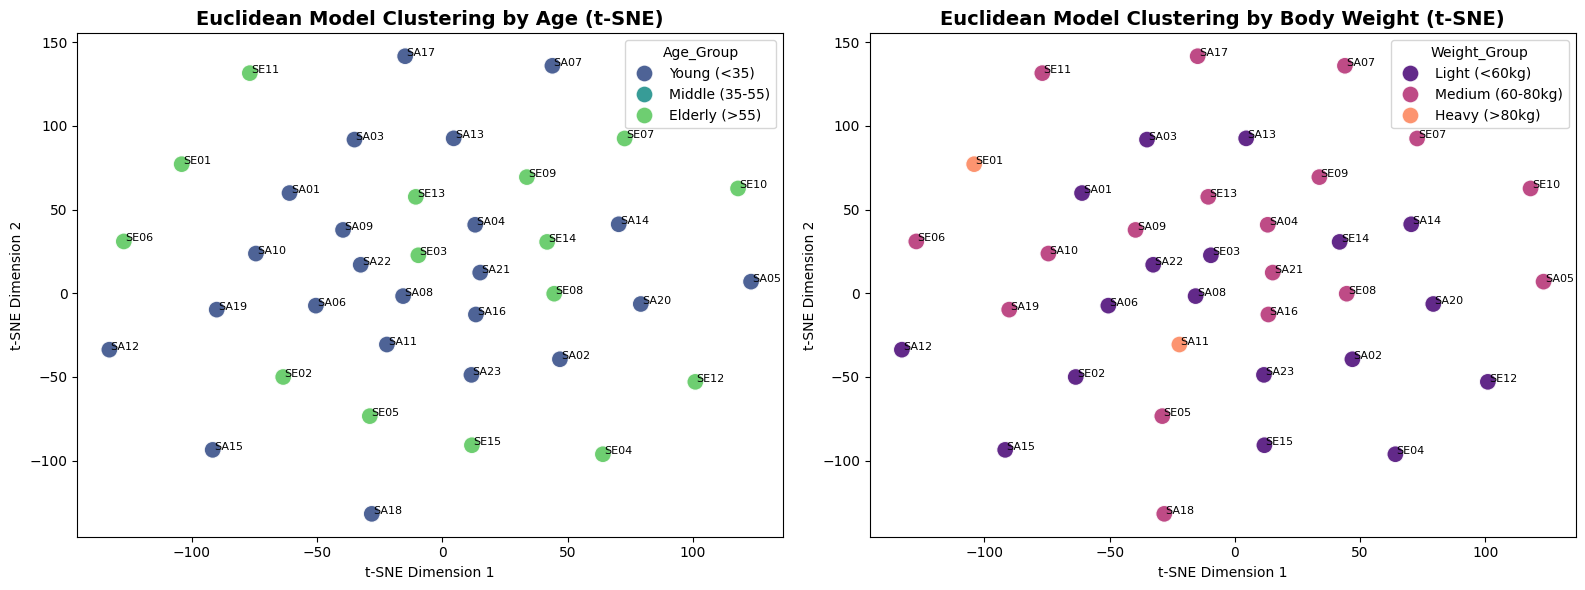

In [ ]:
# Cell 4: Euclidean Distance & t-SNE Visualization
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def get_flattened_weights(model):
    """Extracts and flattens all weights from a trained model."""
    weights = model.get_weights()
    return np.concatenate([w.flatten() for w in weights])

# 1. Extract weights from our dictionary of trained models
subject_ids_trained = list(personalized_models.keys())
flattened_weights_list = [get_flattened_weights(personalized_models[subj]) for subj in subject_ids_trained]
weight_matrix = np.array(flattened_weights_list)

print(f"Weight Matrix extracted. Shape: {weight_matrix.shape}")
print("Computing Euclidean distances and optimizing t-SNE clusters... (This takes a few seconds)")

# 2. Apply t-SNE using strict Euclidean metric
# Perplexity is set low (e.g., 10) because our sample size (number of subjects) is around ~38
tsne = TSNE(n_components=2, metric='euclidean', perplexity=10, random_state=42, init='pca', learning_rate='auto')
weights_2d_tsne = tsne.fit_transform(weight_matrix)

# 3. Format the data for our scatter plots
plot_data_tsne = pd.DataFrame({
    'Subject': subject_ids_trained,
    'tSNE_1': weights_2d_tsne[:, 0],
    'tSNE_2': weights_2d_tsne[:, 1],
    'Age': [subject_demographics[s]['Age'] for s in subject_ids_trained],
    'Weight': [subject_demographics[s]['Weight'] for s in subject_ids_trained]
})

# Create our demographic groups again
plot_data_tsne['Age_Group'] = pd.cut(plot_data_tsne['Age'], bins=[0, 35, 55, 100], labels=['Young (<35)', 'Middle (35-55)', 'Elderly (>55)'])
plot_data_tsne['Weight_Group'] = pd.cut(plot_data_tsne['Weight'], bins=[0, 60, 80, 150], labels=['Light (<60kg)', 'Medium (60-80kg)', 'Heavy (>80kg)'])

# 4. Plot the Euclidean Clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Age
sns.scatterplot(data=plot_data_tsne, x='tSNE_1', y='tSNE_2', hue='Age_Group', palette='viridis', s=150, alpha=0.9, edgecolor='white', ax=axes[0])
axes[0].set_title('Euclidean Model Clustering by Age (t-SNE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')

# Plot 2: Weight
sns.scatterplot(data=plot_data_tsne, x='tSNE_1', y='tSNE_2', hue='Weight_Group', palette='magma', s=150, alpha=0.9, edgecolor='white', ax=axes[1])
axes[1].set_title('Euclidean Model Clustering by Body Weight (t-SNE)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')

# Add Subject ID labels slightly offset from the dots
for i in range(plot_data_tsne.shape[0]):
    axes[0].text(plot_data_tsne['tSNE_1'][i]+0.5, plot_data_tsne['tSNE_2'][i], plot_data_tsne['Subject'][i], fontsize=8)
    axes[1].text(plot_data_tsne['tSNE_1'][i]+0.5, plot_data_tsne['tSNE_2'][i], plot_data_tsne['Subject'][i], fontsize=8)

plt.tight_layout()
plt.show()

Weight Matrix extracted. Shape: (38, 1043810)


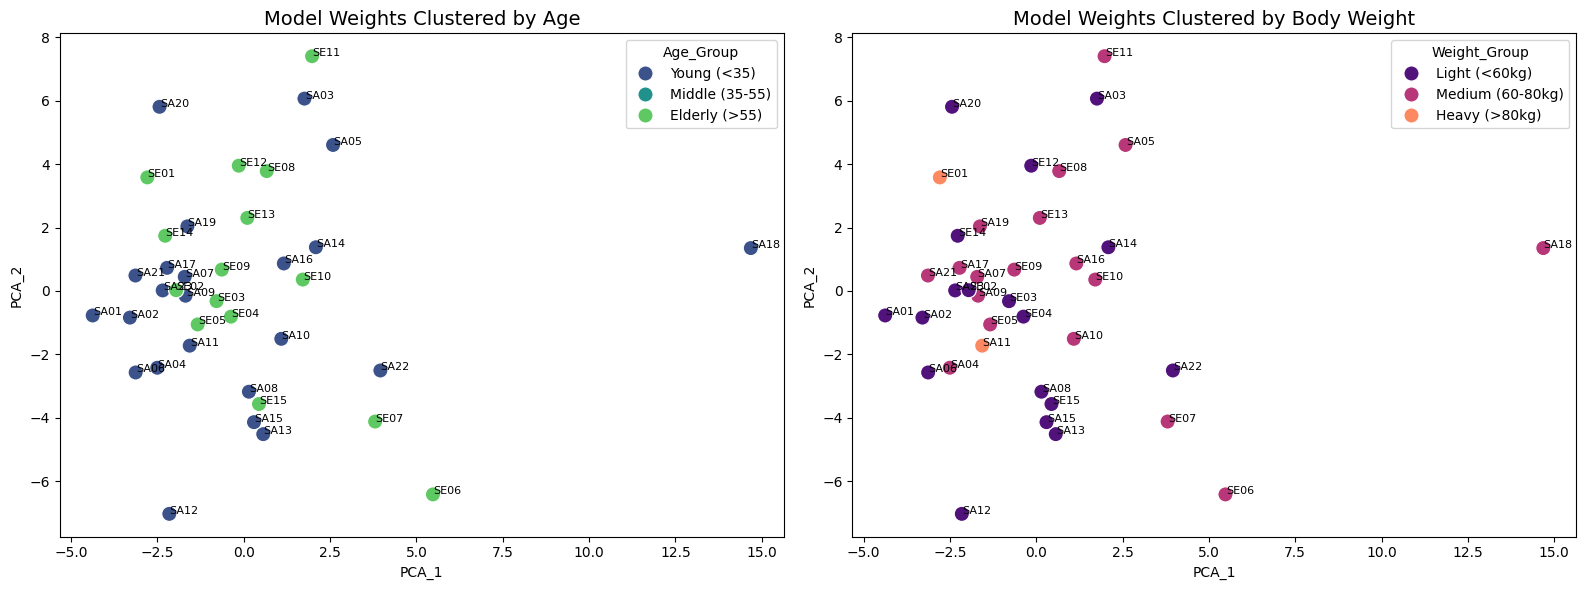

In [ ]:
# Cell 4: Weight Similarity & Visualization

def get_flattened_weights(model):
    weights = model.get_weights()
    return np.concatenate([w.flatten() for w in weights])

subject_ids_trained = list(personalized_models.keys())
flattened_weights_list = [get_flattened_weights(personalized_models[subj]) for subj in subject_ids_trained]
weight_matrix = np.array(flattened_weights_list)

print(f"Weight Matrix extracted. Shape: {weight_matrix.shape}")

# Reduce dimensions for 2D plotting
pca = PCA(n_components=3)
weights_2d = pca.fit_transform(weight_matrix)

# Format data for Seaborn
plot_data = pd.DataFrame({
    'Subject': subject_ids_trained,
    'PCA_1': weights_2d[:, 0],
    'PCA_2': weights_2d[:, 1],
    'PCA_3': weights_2d[:, 2],
    'Age': [subject_demographics[s]['Age'] for s in subject_ids_trained],
    'Weight': [subject_demographics[s]['Weight'] for s in subject_ids_trained]
})

plot_data['Age_Group'] = pd.cut(plot_data['Age'], bins=[0, 35, 55, 100], labels=['Young (<35)', 'Middle (35-55)', 'Elderly (>55)'])
plot_data['Weight_Group'] = pd.cut(plot_data['Weight'], bins=[0, 60, 80, 150], labels=['Light (<60kg)', 'Medium (60-80kg)', 'Heavy (>80kg)'])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=plot_data, x='PCA_1', y='PCA_2', hue='Age_Group', palette='viridis', s=120, ax=axes[0])
axes[0].set_title('Model Weights Clustered by Age', fontsize=14)

sns.scatterplot(data=plot_data, x='PCA_1', y='PCA_2', hue='Weight_Group', palette='magma', s=120, ax=axes[1])
axes[1].set_title('Model Weights Clustered by Body Weight', fontsize=14)

# Label each point with the Subject ID
for i in range(plot_data.shape[0]):
    axes[0].text(plot_data['PCA_1'][i]+0.01, plot_data['PCA_2'][i], plot_data['Subject'][i], fontsize=8)
    axes[1].text(plot_data['PCA_1'][i]+0.01, plot_data['PCA_2'][i], plot_data['Subject'][i], fontsize=8)

plt.tight_layout()
plt.show()

Calculating PCA and t-SNE... Please wait.


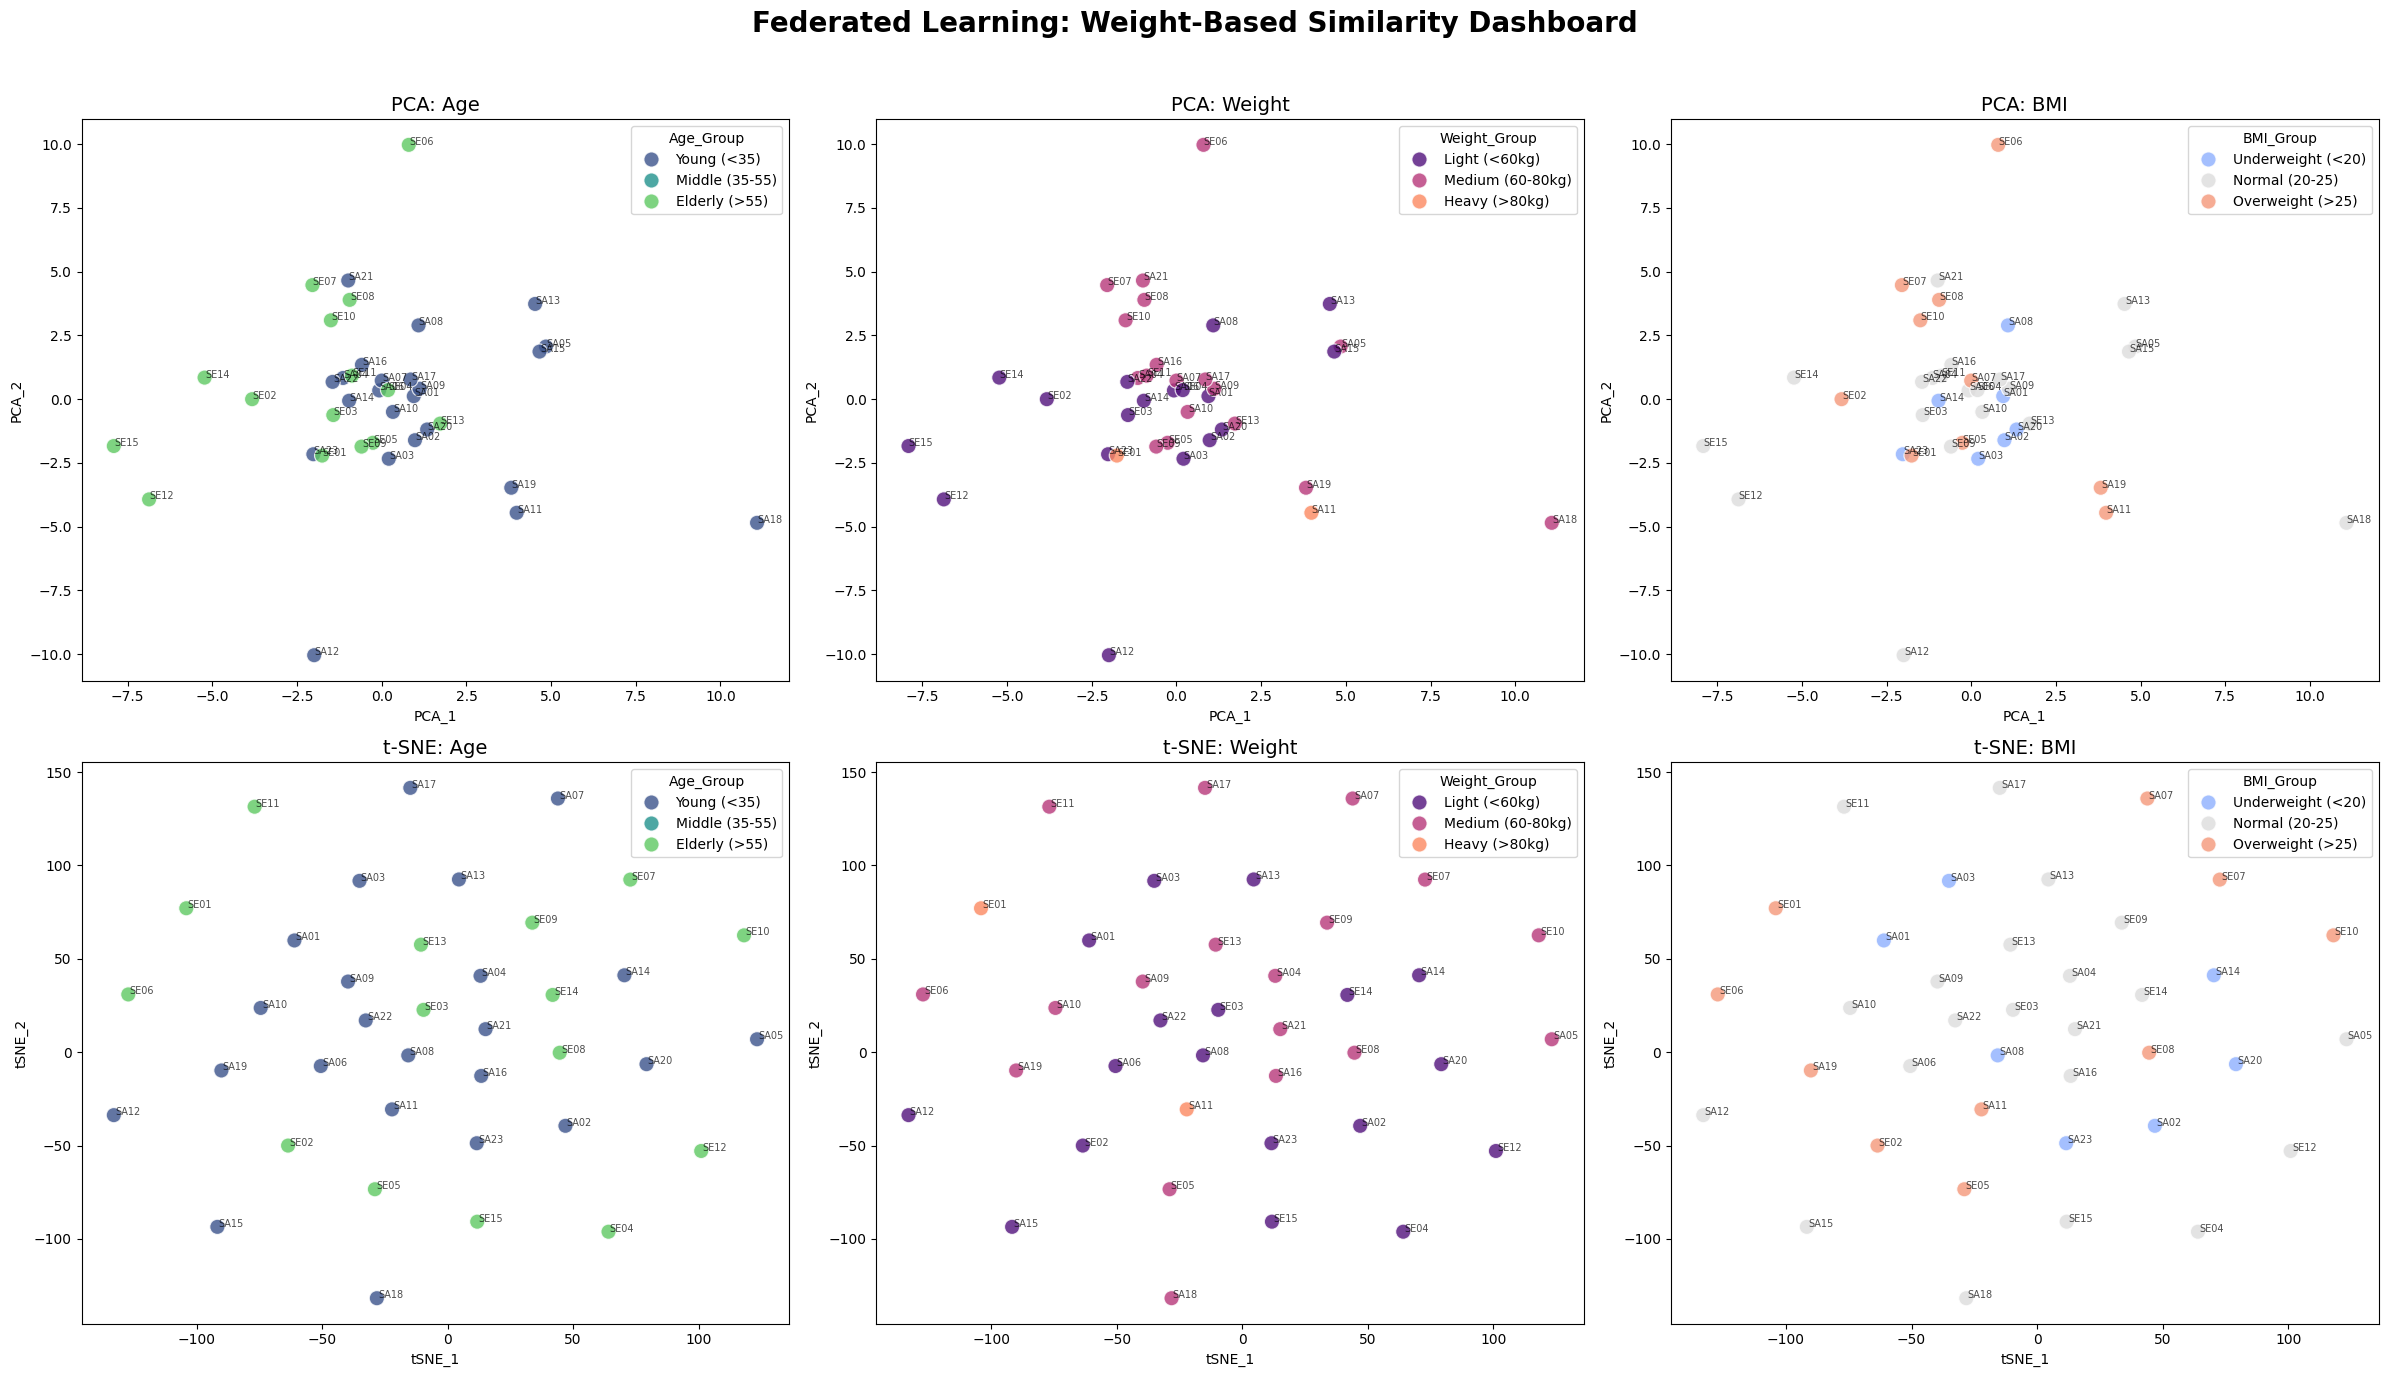

In [ ]:
# Cell 5: The Master CFL Clustering Dashboard
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Extract raw weights (if not already done)
subject_ids_trained = list(personalized_models.keys())
weight_matrix = np.array([np.concatenate([w.flatten() for w in personalized_models[s].get_weights()]) for s in subject_ids_trained])

print("Calculating PCA and t-SNE... Please wait.")
# 2. Calculate PCA (Preserves global macro-structures)
pca = PCA(n_components=2)
weights_pca = pca.fit_transform(weight_matrix)

# 3. Calculate t-SNE (Preserves local micro-structures)
tsne = TSNE(n_components=2, metric='euclidean', perplexity=10, random_state=42, init='pca', learning_rate='auto')
weights_tsne = tsne.fit_transform(weight_matrix)

# 4. Build the comprehensive dataframe with new metrics (Height & BMI)
plot_data = pd.DataFrame({
    'Subject': subject_ids_trained,
    'PCA_1': weights_pca[:, 0], 'PCA_2': weights_pca[:, 1],
    'tSNE_1': weights_tsne[:, 0], 'tSNE_2': weights_tsne[:, 1],
    'Age': [subject_info[s]['Age'] for s in subject_ids_trained],
    'Weight': [subject_info[s]['Weight'] for s in subject_ids_trained],
    'Height': [subject_info[s]['Height'] for s in subject_ids_trained]
})

# Calculate Body Mass Index (BMI)
plot_data['BMI'] = plot_data['Weight'] / ((plot_data['Height'] / 100) ** 2)

# Create Categorical Bins for coloring
plot_data['Age_Group'] = pd.cut(plot_data['Age'], bins=[0, 35, 55, 100], labels=['Young (<35)', 'Middle (35-55)', 'Elderly (>55)'])
plot_data['Weight_Group'] = pd.cut(plot_data['Weight'], bins=[0, 60, 80, 150], labels=['Light (<60kg)', 'Medium (60-80kg)', 'Heavy (>80kg)'])
plot_data['BMI_Group'] = pd.cut(plot_data['BMI'], bins=[0, 20, 25, 50], labels=['Underweight (<20)', 'Normal (20-25)', 'Overweight (>25)'])

# 5. Plotting the Master Dashboard (2 Rows x 3 Columns)
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('Federated Learning: Weight-Based Similarity Dashboard', fontsize=20, fontweight='bold', y=0.98)

plot_configs = [
    {'x': 'PCA_1', 'y': 'PCA_2', 'hue': 'Age_Group', 'title': 'PCA: Age', 'ax': axes[0,0], 'palette': 'viridis'},
    {'x': 'PCA_1', 'y': 'PCA_2', 'hue': 'Weight_Group', 'title': 'PCA: Weight', 'ax': axes[0,1], 'palette': 'magma'},
    {'x': 'PCA_1', 'y': 'PCA_2', 'hue': 'BMI_Group', 'title': 'PCA: BMI', 'ax': axes[0,2], 'palette': 'coolwarm'},
    {'x': 'tSNE_1', 'y': 'tSNE_2', 'hue': 'Age_Group', 'title': 't-SNE: Age', 'ax': axes[1,0], 'palette': 'viridis'},
    {'x': 'tSNE_1', 'y': 'tSNE_2', 'hue': 'Weight_Group', 'title': 't-SNE: Weight', 'ax': axes[1,1], 'palette': 'magma'},
    {'x': 'tSNE_1', 'y': 'tSNE_2', 'hue': 'BMI_Group', 'title': 't-SNE: BMI', 'ax': axes[1,2], 'palette': 'coolwarm'}
]

for config in plot_configs:
    sns.scatterplot(data=plot_data, x=config['x'], y=config['y'], hue=config['hue'], palette=config['palette'], s=120, alpha=0.8, edgecolor='white', ax=config['ax'])
    config['ax'].set_title(config['title'], fontsize=14)
    # Add subject labels
    for i in range(plot_data.shape[0]):
        config['ax'].text(plot_data[config['x']][i] + (0.5 if 'tSNE' in config['x'] else 0.01),
                          plot_data[config['y']][i],
                          plot_data['Subject'][i], fontsize=7, alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

--- INITIATING CLUSTERED FEDERATED LEARNING (CFL) SERVER ROUTINE ---
Goal: Group users based purely on Model Weight Cosine Similarity.
Constraint: The Server is 100% blind to Age, Weight, and Height.

Step 1: Calculating Cosine Distances between all personalized models...
Step 2: Building the Hierarchical Tree (Linkage)...
        -> The server pairs up the two most mathematically similar models.
        -> It merges them, then looks for the next closest pair.
Step 3: Slicing the hierarchical tree to form 5 distinct server clusters...


/tmp/ipykernel_7615/3621839318.py:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix, method='average', metric='cosine')


Step 4: Compressing high-dimensional weights to 2D (PCA) for our visual dashboard...

--- GENERATING VISUALIZATIONS ---


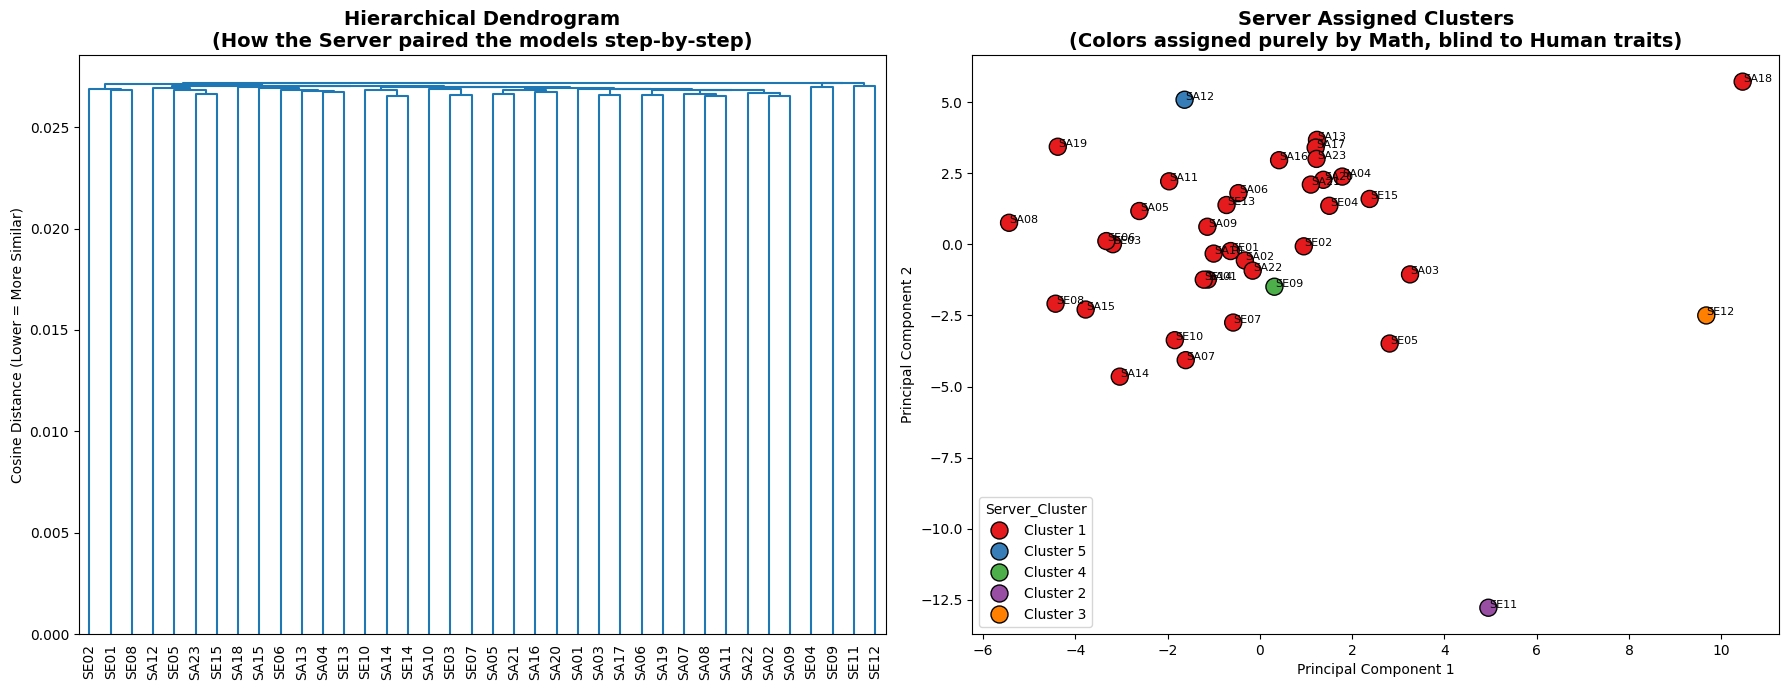


--- THE REVEAL: SERVER CLUSTER DEMOGRAPHIC ANALYSIS ---
Even though the server ONLY saw model weights, look at the actual
physical traits of the humans it grouped together:

                Number_of_Subjects  Average_Age  Min_Age  Max_Age  Average_BMI
Server_Cluster                                                                
Cluster 1                       34         38.2     19.0     75.0         23.2
Cluster 2                        1         66.0     66.0     66.0         22.1
Cluster 3                        1         69.0     69.0     69.0         21.0
Cluster 4                        1         66.0     66.0     66.0         23.3
Cluster 5                        1         25.0     25.0     25.0         20.1

Thought Experiment Complete!


In [ ]:
# Cell 6: The CFL Server Simulation - Agglomerative Clustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import cosine_distances

print("=====================================================================")
print("--- INITIATING CLUSTERED FEDERATED LEARNING (CFL) SERVER ROUTINE ---")
print("Goal: Group users based purely on Model Weight Cosine Similarity.")
print("Constraint: The Server is 100% blind to Age, Weight, and Height.")
print("=====================================================================\n")

# 1. Extract weights from our dictionary of trained models (if not already in memory)
subject_ids_trained = list(personalized_models.keys())
flattened_weights_list = [np.concatenate([w.flatten() for w in personalized_models[subj].get_weights()]) for subj in subject_ids_trained]
weight_matrix = np.array(flattened_weights_list)

# 2. Calculate Cosine Distance (1 - Cosine Similarity)
print("Step 1: Calculating Cosine Distances between all personalized models...")
dist_matrix = cosine_distances(weight_matrix)

# 3. Perform Hierarchical Clustering (Linkage)
print("Step 2: Building the Hierarchical Tree (Linkage)...")
print("        -> The server pairs up the two most mathematically similar models.")
print("        -> It merges them, then looks for the next closest pair.")
# 'average' linkage works exceptionally well with cosine distance
Z = linkage(dist_matrix, method='average', metric='cosine')

# 4. Cut the tree into distinct groups
NUM_CLUSTERS = 5
print(f"Step 3: Slicing the hierarchical tree to form {NUM_CLUSTERS} distinct server clusters...")
# We use sklearn's AgglomerativeClustering to easily assign labels (0, 1, or 2) to each user
cluster_model = AgglomerativeClustering(n_clusters=NUM_CLUSTERS, metric='cosine', linkage='average')
assigned_clusters = cluster_model.fit_predict(weight_matrix)

print("Step 4: Compressing high-dimensional weights to 2D (PCA) for our visual dashboard...\n")
pca = PCA(n_components=2)
weights_pca = pca.fit_transform(weight_matrix)

# 5. Let's calculate BMI for our own research analysis (The server didn't use this!)
bmis = []
ages = []
for s in subject_ids_trained:
    w = subject_demographics[s]['Weight']
    # We pull Height directly from the main lookup table we built in Cell 1
    h_meters = subject_info[s]['Height'] / 100
    bmi = w / (h_meters * h_meters) # BMI = Weight (kg) / Height (m)^2

    bmis.append(bmi)
    ages.append(subject_demographics[s]['Age'])

# Build a dataframe for easy plotting and analysis
server_df = pd.DataFrame({
    'Subject': subject_ids_trained,
    'PCA_1': weights_pca[:, 0],
    'PCA_2': weights_pca[:, 1],
    'Server_Cluster': [f"Cluster {c+1}" for c in assigned_clusters], # Name them Cluster 1, 2, 3
    'Age': ages,
    'BMI': bmis
})

print("--- GENERATING VISUALIZATIONS ---")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: The Dendrogram (The Server's "Family Tree" of Models)
axes[0].set_title("Hierarchical Dendrogram\n(How the Server paired the models step-by-step)", fontsize=14, fontweight='bold')
dendrogram(Z, labels=subject_ids_trained, ax=axes[0], leaf_rotation=90, leaf_font_size=10, color_threshold=0.7*max(Z[:,2]))
axes[0].set_ylabel('Cosine Distance (Lower = More Similar)')

# Plot 2: PCA colored by the Server's Blind Assignment
sns.scatterplot(data=server_df, x='PCA_1', y='PCA_2', hue='Server_Cluster', palette='Set1', s=150, edgecolor='black', ax=axes[1])
axes[1].set_title(f"Server Assigned Clusters\n(Colors assigned purely by Math, blind to Human traits)", fontsize=14, fontweight='bold')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

# Add subject labels to the scatter plot
for i in range(server_df.shape[0]):
    axes[1].text(server_df['PCA_1'][i]+0.01, server_df['PCA_2'][i], server_df['Subject'][i], fontsize=8)

plt.tight_layout()
plt.show()

# 6. The Big Reveal: Let's look at the physical traits of the math-generated clusters!
print("\n=====================================================================")
print("--- THE REVEAL: SERVER CLUSTER DEMOGRAPHIC ANALYSIS ---")
print("Even though the server ONLY saw model weights, look at the actual")
print("physical traits of the humans it grouped together:")
print("=====================================================================\n")

# Group the dataframe by the Server's assigned clusters and calculate the average Age and BMI
analysis = server_df.groupby('Server_Cluster').agg(
    Number_of_Subjects=('Subject', 'count'),
    Average_Age=('Age', 'mean'),
    Min_Age=('Age', 'min'),
    Max_Age=('Age', 'max'),
    Average_BMI=('BMI', 'mean')
).round(1)

print(analysis.to_string())
print("\nThought Experiment Complete!")

Running sequential cluster simulations for multiple K thresholds...


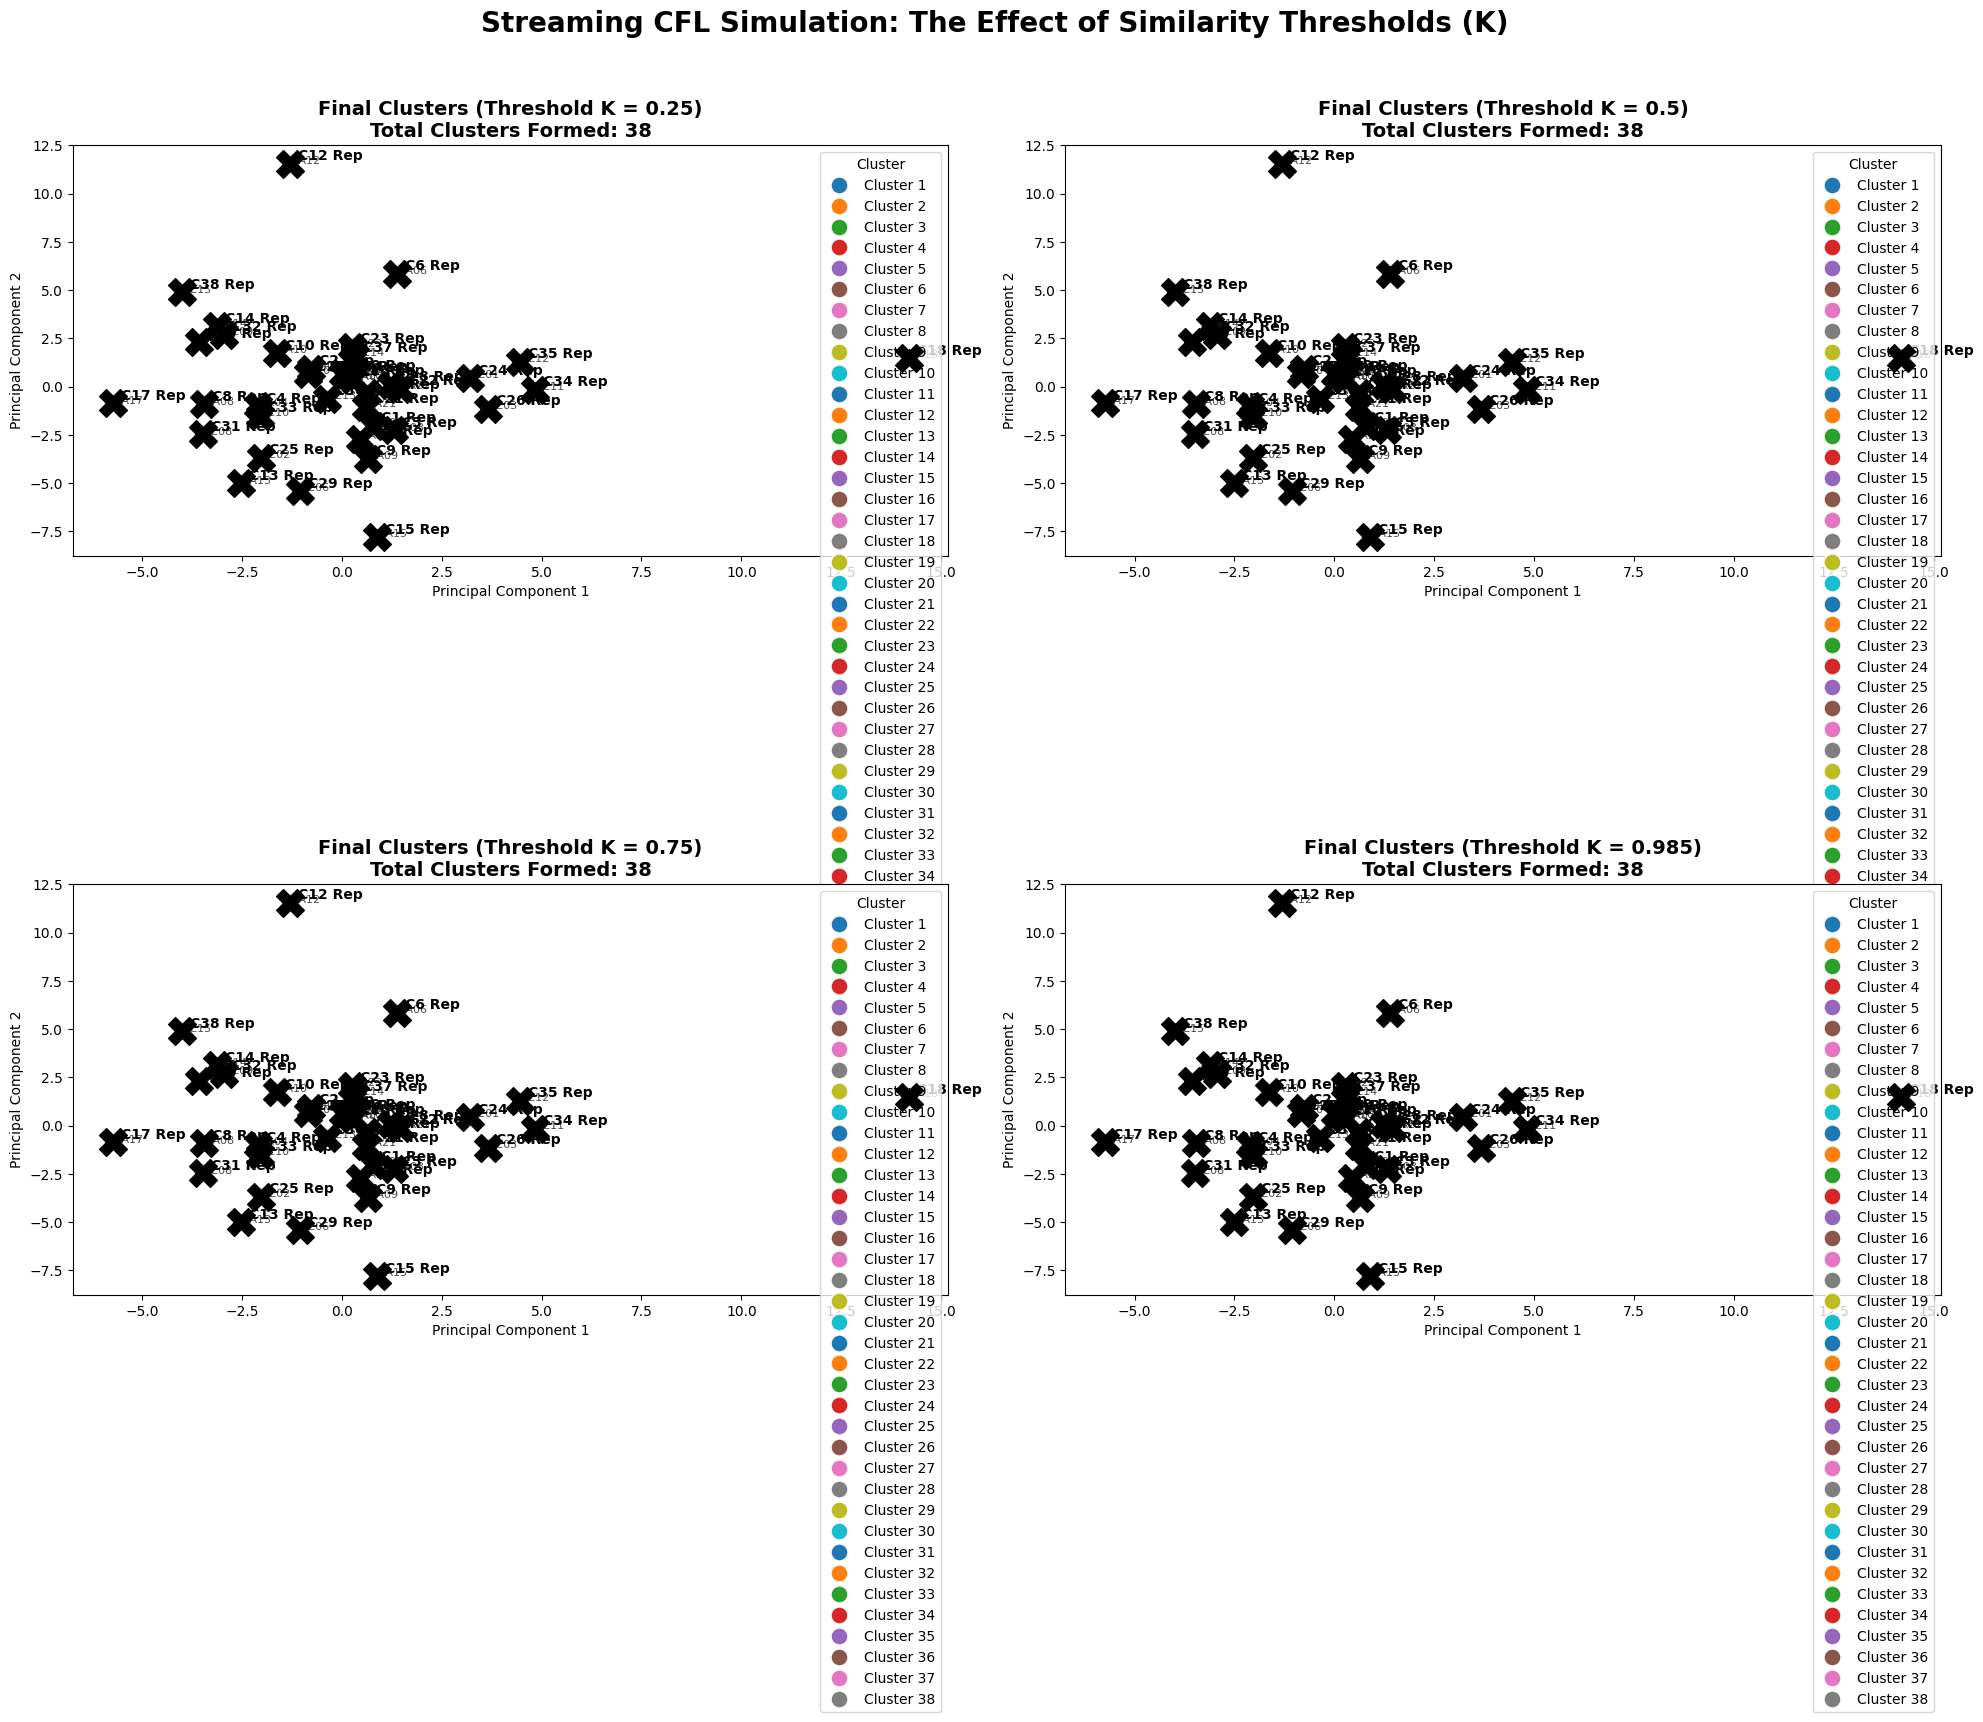

In [ ]:
# Cell 7: Online/Streaming CFL Simulation (Static Multi-Plot Comparison)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

print("Running sequential cluster simulations for multiple K thresholds...")

# 1. Extract weights (if not already in memory)
subject_ids_trained = list(personalized_models.keys())
weight_matrix = np.array([np.concatenate([w.flatten() for w in personalized_models[subj].get_weights()]) for subj in subject_ids_trained])

# 2. Pre-compute Global PCA coordinates so the X/Y axes are identical across all plots
pca = PCA(n_components=2)
weights_pca = pca.fit_transform(weight_matrix)
pca_dict = {subj: weights_pca[i] for i, subj in enumerate(subject_ids_trained)}

def simulate_streaming_cfl_final_state(k_threshold):
    """Runs the online clustering simulation and returns the final state."""
    clusters = {}           # Maps Cluster_ID -> List of Subject IDs
    representatives = {}    # Maps Cluster_ID -> Mean Weight Vector (The Representative)
    assigned_clusters = {}  # Maps Subject_ID -> Cluster_ID

    for current_subject in subject_ids_trained:
        w_incoming = weight_matrix[subject_ids_trained.index(current_subject)].reshape(1, -1)

        # First model creates the first cluster
        if len(clusters) == 0:
            clusters[1] = [current_subject]
            representatives[1] = w_incoming
            assigned_clusters[current_subject] = 1
        else:
            rep_ids = list(representatives.keys())
            rep_matrix = np.vstack([representatives[c] for c in rep_ids])

            # Find the most similar existing representative
            sims = cosine_similarity(w_incoming, rep_matrix)[0]
            best_match_idx = np.argmax(sims)
            best_sim_score = sims[best_match_idx]
            best_cluster_id = rep_ids[best_match_idx]

            # Threshold Check
            if best_sim_score >= k_threshold:
                # Add to cluster and update the representative (mean)
                clusters[best_cluster_id].append(current_subject)
                assigned_clusters[current_subject] = best_cluster_id
                cluster_weights = np.array([weight_matrix[subject_ids_trained.index(s)] for s in clusters[best_cluster_id]])
                representatives[best_cluster_id] = np.mean(cluster_weights, axis=0).reshape(1, -1)
            else:
                # Spawn a new cluster
                new_id = max(rep_ids) + 1
                clusters[new_id] = [current_subject]
                representatives[new_id] = w_incoming
                assigned_clusters[current_subject] = new_id

    # Format output for plotting
    plot_df = pd.DataFrame({
        'Subject': subject_ids_trained,
        'PCA_1': [pca_dict[s][0] for s in subject_ids_trained],
        'PCA_2': [pca_dict[s][1] for s in subject_ids_trained],
        'Cluster': [f"Cluster {assigned_clusters[s]}" for s in subject_ids_trained]
    })
    return plot_df, representatives

# 3. Setup the 2x2 Grid Plot
k_values_to_test = [0.25, 0.50, 0.75, 0.985]
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

# 4. Run simulation and plot for each threshold
for idx, k in enumerate(k_values_to_test):
    plot_df, reps = simulate_streaming_cfl_final_state(k)

    # Plot the users
    sns.scatterplot(data=plot_df, x='PCA_1', y='PCA_2', hue='Cluster', palette='tab10', s=150, edgecolor='white', ax=axes[idx])

    # Plot the Final Cluster Representatives (The Black 'X')
    for c_id, rep_w in reps.items():
        rep_pca = pca.transform(rep_w)
        axes[idx].scatter(rep_pca[0,0], rep_pca[0,1], marker='X', s=400, color='black', zorder=10)
        axes[idx].text(rep_pca[0,0]+0.2, rep_pca[0,1]+0.2, f"C{c_id} Rep", fontsize=10, fontweight='bold')

    # Add subject labels
    for _, row in plot_df.iterrows():
        axes[idx].text(row['PCA_1']+0.03, row['PCA_2'], row['Subject'], fontsize=8, alpha=0.7)

    axes[idx].set_title(f"Final Clusters (Threshold K = {k})\nTotal Clusters Formed: {len(reps)}", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Principal Component 1')
    axes[idx].set_ylabel('Principal Component 2')

plt.suptitle('Streaming CFL Simulation: The Effect of Similarity Thresholds (K)', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# second simulation algorithm

In [ ]:
# Cell 8: Federated Learning Shared Initialization Fix
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tqdm import tqdm

print("=====================================================================")
print("--- STAGE 1: GLOBAL MODEL BROADCAST ---")
print("=====================================================================")

# 1. Create the Global Base Model (The Server's blank slate)
global_model = build_multiclass_model(input_shape=(512, 9), num_classes=34)
global_initial_weights = global_model.get_weights()
print("Global Base Model initialized. Broadcasting weights to all clients...\n")

personalized_models_fixed = {}
unique_subjects = np.unique(y_subject)

# 2. Re-train all local models from this shared starting point
print(f"Re-training {len(unique_subjects)} local models...")

for subject in tqdm(unique_subjects):
    subject_mask = (y_subject == subject)
    X_local = X_all[subject_mask]
    y_local = y_activity[subject_mask]

    X_train, X_test, y_train, y_test = train_test_split(X_local, y_local, test_size=0.2, random_state=42)

    # Initialize a new local model
    local_model = build_multiclass_model(input_shape=(512, 9), num_classes=34)

    # CRITICAL FIX: Overwrite the random weights with the Global Weights!
    local_model.set_weights(global_initial_weights)

    # Train on local data for 5 epochs
    local_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

    personalized_models_fixed[subject] = local_model

print("\nRe-training complete! All models diverged from the exact same mathematical origin.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- STAGE 1: GLOBAL MODEL BROADCAST ---
Global Base Model initialized. Broadcasting weights to all clients...

Re-training 38 local models...


100%|██████████| 38/38 [05:57<00:00,  9.42s/it]


Re-training complete! All models diverged from the exact same mathematical origin.


Extracting the newly fixed weights...
 -> Simulating Threshold K = 0.5...
 -> Simulating Threshold K = 0.9...
 -> Simulating Threshold K = 0.98...
 -> Simulating Threshold K = 0.99...

Generating final visualization...


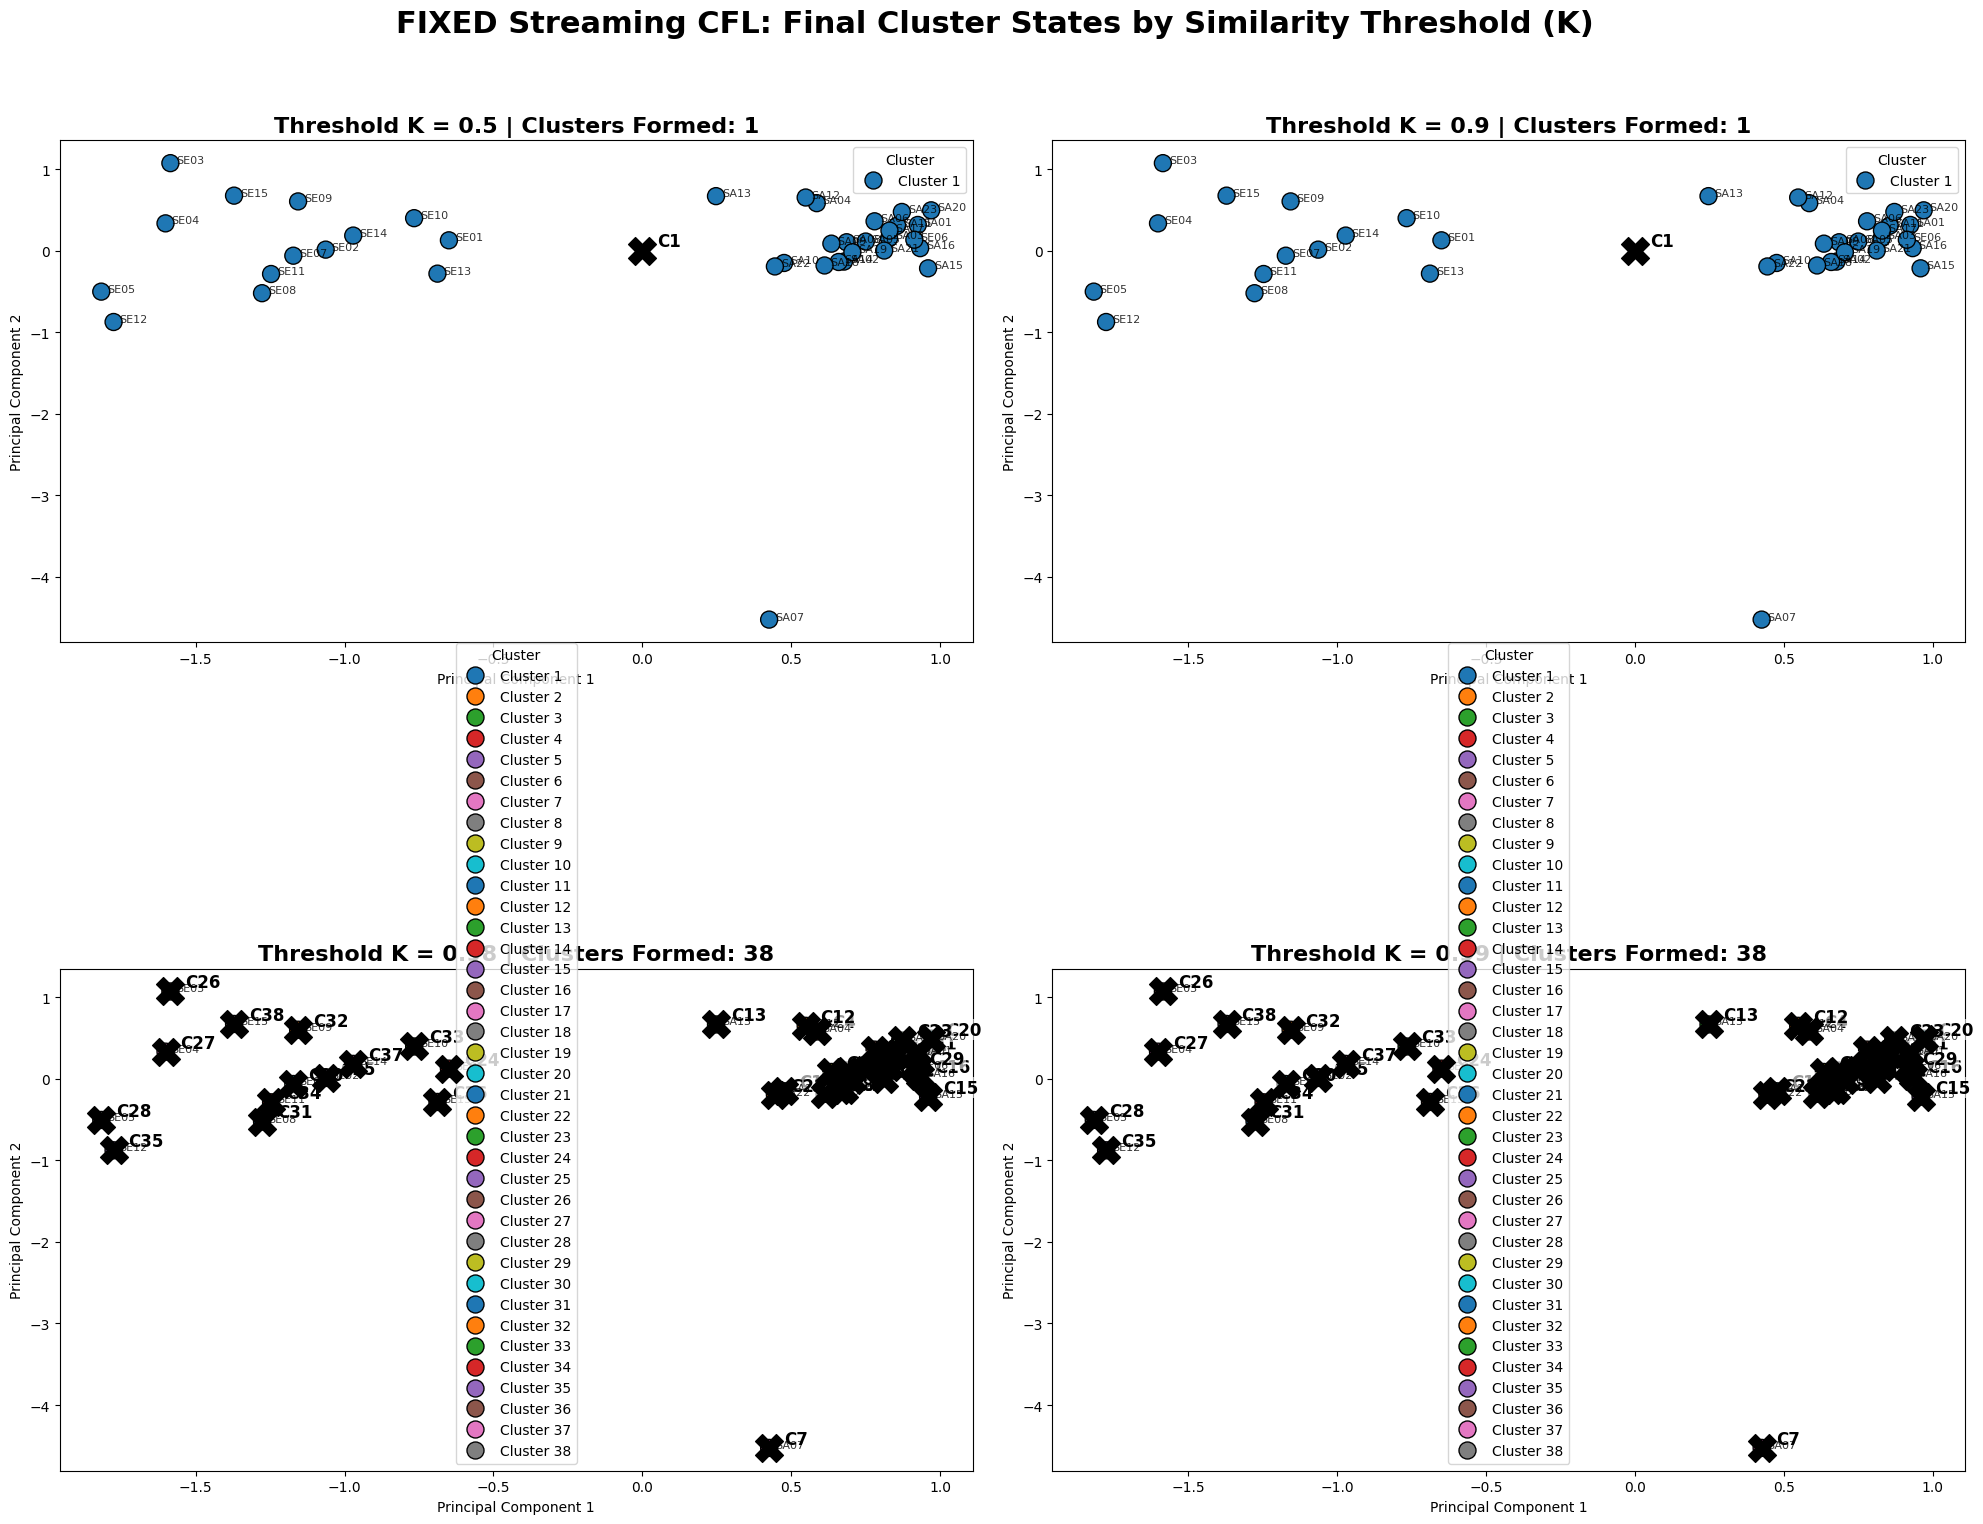

In [ ]:
# Cell 9: The Fixed Streaming Simulation Dashboard
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

print("Extracting the newly fixed weights...")

# 1. Extract the fixed weights
subject_ids_trained = list(personalized_models_fixed.keys())
weight_matrix_fixed = np.array([np.concatenate([w.flatten() for w in personalized_models_fixed[subj].get_weights()]) for subj in subject_ids_trained])

# 2. Pre-compute Global PCA for consistent plotting
pca_fixed = PCA(n_components=2)
weights_pca_fixed = pca_fixed.fit_transform(weight_matrix_fixed)
pca_dict_fixed = {subj: weights_pca_fixed[i] for i, subj in enumerate(subject_ids_trained)}

def run_streaming_cfl_fixed(k_threshold):
    clusters = {}
    representatives = {}
    assigned_clusters = {}

    for current_subject in subject_ids_trained:
        w_incoming = weight_matrix_fixed[subject_ids_trained.index(current_subject)].reshape(1, -1)

        if len(clusters) == 0:
            clusters[1] = [current_subject]
            representatives[1] = w_incoming
            assigned_clusters[current_subject] = 1
        else:
            rep_ids = list(representatives.keys())
            rep_matrix = np.vstack([representatives[c] for c in rep_ids])

            sims = cosine_similarity(w_incoming, rep_matrix)[0]
            best_match_idx = np.argmax(sims)
            best_sim_score = sims[best_match_idx]
            best_cluster_id = rep_ids[best_match_idx]

            if best_sim_score >= k_threshold:
                clusters[best_cluster_id].append(current_subject)
                assigned_clusters[current_subject] = best_cluster_id

                # Update Cluster Representative Mean
                cluster_weights = np.array([weight_matrix_fixed[subject_ids_trained.index(s)] for s in clusters[best_cluster_id]])
                representatives[best_cluster_id] = np.mean(cluster_weights, axis=0).reshape(1, -1)
            else:
                new_id = max(rep_ids) + 1
                clusters[new_id] = [current_subject]
                representatives[new_id] = w_incoming
                assigned_clusters[current_subject] = new_id

    return assigned_clusters, representatives

# 3. Run the simulation for High-Sensitivity thresholds
k_values = [0.50, 0.90, 0.98, 0.99]
results = {}

for k in k_values:
    print(f" -> Simulating Threshold K = {k}...")
    results[k] = run_streaming_cfl_fixed(k)

# 4. Plot the massive 2x2 comparison dashboard
print("\nGenerating final visualization...")
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('FIXED Streaming CFL: Final Cluster States by Similarity Threshold (K)', fontsize=22, fontweight='bold')
axes = axes.flatten()

for idx, k in enumerate(k_values):
    assigned_clusters, representatives = results[k]

    plot_df = pd.DataFrame({
        'Subject': subject_ids_trained,
        'PCA_1': [pca_dict_fixed[s][0] for s in subject_ids_trained],
        'PCA_2': [pca_dict_fixed[s][1] for s in subject_ids_trained],
        'Cluster': [f"Cluster {assigned_clusters[s]}" for s in subject_ids_trained]
    })

    ax = axes[idx]

    sns.scatterplot(data=plot_df, x='PCA_1', y='PCA_2', hue='Cluster', palette='tab10', s=150, edgecolor='black', ax=ax, legend='full')

    # Plot the Cluster Representatives (The Black 'X')
    for c_id, rep_w in representatives.items():
        rep_pca = pca_fixed.transform(rep_w)
        ax.scatter(rep_pca[0,0], rep_pca[0,1], marker='X', s=400, color='black', zorder=10)
        ax.text(rep_pca[0,0]+0.05, rep_pca[0,1]+0.05, f"C{c_id}", fontsize=12, fontweight='bold', color='black', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    for _, row in plot_df.iterrows():
        ax.text(row['PCA_1']+0.02, row['PCA_2'], row['Subject'], fontsize=8, alpha=0.8)

    ax.set_title(f"Threshold K = {k} | Clusters Formed: {len(representatives)}", fontsize=16, fontweight='bold')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# WEDA fall dataset trails


In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Then clone it into your drive
%cd /content/drive/MyDrive/
!git clone https://github.com/joaojtmarques/WEDA-FALL.git

ModuleNotFoundError: No module named 'google'

In [2]:
from IPython.display import display, Markdown

with open('/content/drive/MyDrive/WEDA-FALL/README.md', 'r') as f:
    content = f.read()

display(Markdown(content))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/WEDA-FALL/README.md'

In [ ]:
import csv
import pandas as pd

path  = '/content/drive/MyDrive/WEDA-FALL/dataset/10Hz/F08/U01_R01_accel.csv'
df = pd.read_csv(path)

In [ ]:
df

,accel_time_list,accel_x_list,accel_y_list,accel_z_list
0,0.125,-0.1,1.8,9.3
1,0.229,-0.1,2.9,9.4
2,0.242,-0.3,2.7,9.4
3,0.348,0.0,2.6,9.3
4,0.432,-2.0,4.6,9.4
...,...,...,...,...
158,16.033,3.7,6.6,-5.7
159,16.138,3.7,6.9,-5.5
160,16.233,3.5,7.3,-5.8
161,16.328,3.1,6.5,-6.4


In [ ]:
path2 = '/content/drive/MyDrive/WEDA-FALL/dataset/10Hz/F08/U01_R01_accel.csv'
df2 = pd.read_csv(path2)


In [ ]:
df2


,accel_time_list,accel_x_list,accel_y_list,accel_z_list
0,0.125,-0.1,1.8,9.3
1,0.229,-0.1,2.9,9.4
2,0.242,-0.3,2.7,9.4
3,0.348,0.0,2.6,9.3
4,0.432,-2.0,4.6,9.4
...,...,...,...,...
158,16.033,3.7,6.6,-5.7
159,16.138,3.7,6.9,-5.5
160,16.233,3.5,7.3,-5.8
161,16.328,3.1,6.5,-6.4


In [4]:
import glob
import numpy as np
import os
import pandas as pd


features_list = []
DATA_PATH = '/content/drive/MyDrive/WEDA-FALL/dataset/10Hz/'

# Loop through all activity folders in 10Hz
totalcount = 0
eachfolderfilecount = 0
for folder in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, folder)
    if os.path.isdir(folder_path):
        # Get all CSVs in that folder
        eachfolderfilecount = 0
        for file_path in glob.glob(f"{folder_path}/*.csv"):
            eachfolderfilecount += 1
            totalcount += 1
            # Read the CSV
            df = pd.read_csv(file_path)
            print("="*80)
            print('file path : ',file_path )
            print(df)
            print("="*80)
            # # Calculate Resultant Acceleration (SMV)
            # # Assuming columns are 'acc_x', 'acc_y', 'acc_z' - check your CSV headers!
            # smv = np.sqrt(df.iloc[:, 0]**2 + df.iloc[:, 1]**2 + df.iloc[:, 2]**2)

            # # Create a feature row
            # features = {
            #     'max_smv': smv.max(),
            #     'std_smv': smv.std(),
            #     'mean_smv': smv.mean(),
            #     'label': 1 if folder.startswith('F') else 0, # 1 for Fall, 0 for ADL
            #     'activity_code': folder
            # }
            # features_list.append(features)
        print('eachfolder count: ',eachfolderfilecount)
print('files count : ',totalcount)

master_df = pd.DataFrame(features_list)

Streaming output truncated to the last 5000 lines.
3                   0.1                 1.0  
4                   0.1                 1.0  
..                  ...                 ...  
113                 0.8                 0.4  
114                 0.8                 0.4  
115                 0.8                 0.5  
116                 0.8                 0.5  
117                 0.8                 0.5  

[118 rows x 5 columns]
file path :  /content/drive/MyDrive/WEDA-FALL/dataset/10Hz/F07/U08_R03_accel.csv
     accel_time_list  accel_x_list  accel_y_list  accel_z_list
0              0.007          -1.4           3.9           8.9
1              0.109           0.5           2.9           8.9
2              0.206           0.1           2.0           9.4
3              0.315          -0.3           2.6           9.3
4              0.381          -1.0           4.3           7.3
..               ...           ...           ...           ...
98             9.918          -0.3 

In [6]:
import glob
import numpy as np
import os
import pandas as pd

features_list = []
DATA_PATH = '/content/drive/MyDrive/WEDA-FALL/dataset/10Hz/'

for folder in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, folder)
    if not os.path.isdir(folder_path):
        continue

    # Group files by trial ID (e.g., 'U08_R03')
    files = glob.glob(f"{folder_path}/*.csv")
    trial_groups = {}

    for f in files:
        # Extract the ID: /.../U08_R03_accel.csv -> U08_R03
        trial_id = os.path.basename(f).rsplit('_', 1)[0]
        if trial_id not in trial_groups:
            trial_groups[trial_id] = {}

        if 'accel' in f: trial_groups[trial_id]['accel'] = f
        elif 'gyro' in f: trial_groups[trial_id]['gyro'] = f
        elif 'orientation' in f: trial_groups[trial_id]['orient'] = f

    for trial_id, paths in trial_groups.items():
        # Ensure we have at least the accelerometer data
        if 'accel' not in paths: continue

        df_acc = pd.read_csv(paths['accel'])
        # Signal Magnitude Vector (SMV) for Acceleration
        smv_acc = np.sqrt(df_acc['accel_x_list']**2 + df_acc['accel_y_list']**2 + df_acc['accel_z_list']**2)

        # Initialize feature row
        features = {
            'trial_id': trial_id,
            'max_accel': smv_acc.max(),
            'mean_accel': smv_acc.mean(),
            'std_accel': smv_acc.std(),
            'label': 1 if folder.startswith('F') else 0,
            'activity_code': folder
        }
        # Add Gyroscope features if file exists
        if 'gyro' in paths:
            df_gyro = pd.read_csv(paths['gyro'])
            smv_gyro = np.sqrt(df_gyro['gyro_x_list']**2 + df_gyro['gyro_y_list']**2 + df_gyro['gyro_z_list']**2)
            features['max_gyro'] = smv_gyro.max()
            features['mean_gyro'] = smv_gyro.mean()

        features_list.append(features)

master_df = pd.DataFrame(features_list)
print(f"Processed {len(master_df)} trials.")
print(master_df.head(50))

Processed 969 trials.
   trial_id  max_accel  mean_accel  std_accel  label activity_code   max_gyro  \
0   U01_R01  14.760081   10.253138   1.565001      0           D01   6.389053   
1   U01_R02  17.158380   10.376998   1.916163      0           D01   5.928744   
2   U01_R03  15.337862   10.332596   1.701039      0           D01   5.068530   
3   U02_R01  15.746111    9.978614   1.265242      0           D01   5.189412   
4   U02_R02  15.711461    9.950607   1.169546      0           D01   4.977951   
5   U02_R03  15.492579    9.933543   1.301925      0           D01   6.483055   
6   U03_R01  22.934908   10.098490   1.894641      0           D01   7.763376   
7   U03_R02  15.852760   10.296513   2.082949      0           D01   8.727543   
8   U03_R03  15.029637   10.159703   1.772938      0           D01   9.669540   
9   U04_R01  23.109738   10.156597   2.413564      0           D01  10.197058   
10  U04_R02  16.063312   10.056077   1.900366      0           D01   4.880574   
11  U0